# Прогнозирование попадания в сборную по бадминтону

Научно-исследовательская работа, 6 семестр, НИЯУ МИФИ.

Собственный датасет: студенты секции бадминтона заполняли шесть тематических
анкет (мотивация, взаимодействие с тренером, баланс учёбы и спорта, режим
восстановления, соревновательный опыт, метакогнитивные навыки), на тренировках
фиксировались физические тесты. Сбор шёл с октября 2025 по апрель 2026.

Задача: предсказать, входит ли спортсмен в сборную института.

## О чём эта работа

52 анкеты и около 100 признаков. При таком размере главный вопрос — не «какая
модель лучше», а «сколько из полученного качества настоящее». Ноутбук устроен
как последовательность проверок.

Порядок разбора:

1. Утечка через отбор признаков до кросс-валидации — сколько она приписывала.
2. Почему из 51 наблюдения в анализ попадали 30 и как вернуть остальные.
3. Информативные пропуски: сам факт заполнения блока анкеты несёт сигнал.
4. Тематические индексы вместо сырых пунктов.
5. Честное сравнение конфигураций и перестановочные тесты.
6. Что из полученного можно утверждать, а что нет.

**Итог.** Возвращение отброшенных наблюдений и переход к тематическим индексам
подняли ROC-AUC с 0.709 до 0.835, а accuracy — с 0.533 (ниже константы) до
0.725 при константе 0.549. Перестановочный тест даёт p = 0.005 против p = 0.073
в первой версии. Причём вариант, где соревновательный блок исключён целиком,
тоже значим: 0.806 при p = 0.005.

## Загрузка и разбор анкет


In [1]:
import sys
from functools import partial

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import (
    StratifiedKFold, RepeatedStratifiedKFold, cross_val_score,
    cross_val_predict, permutation_test_score,
)
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report

sys.path.append(".")
from src.preprocessing import build_features, TARGET_COLUMN
from src.indices import ThematicIndices, INDEX_DEFINITIONS, MISSINGNESS_BLOCKS

SEED = 42
N_SPLITS = 5
N_REPEATS = 10
N_PERMUTATIONS = 200

np.random.seed(SEED)
sns.set_style("whitegrid")

mi_score = partial(mutual_info_classif, random_state=SEED)

Исходные ответы содержат имена участников и свободные текстовые поля, поэтому в
репозитории лежит только разобранная числовая матрица. Код разбора —
в `src/preprocessing.py`, он применим к сырой выгрузке из Google Forms.


In [2]:
RAW_PATH = "data/survey_raw.csv"          # не публикуется
PARSED_PATH = "data/features_parsed.csv"  # то, что лежит в репозитории

try:
    raw = pd.read_csv(RAW_PATH)
    features = build_features(raw)
    target_raw = raw[TARGET_COLUMN]
except FileNotFoundError:
    parsed = pd.read_csv(PARSED_PATH)
    features = parsed.drop(columns=["participant_id", TARGET_COLUMN])
    target_raw = parsed[TARGET_COLUMN]

# целевую знаем не для всех
known = target_raw.notna()
features = features[known].reset_index(drop=True)
target_raw = target_raw[known].reset_index(drop=True)

y = (target_raw >= 1).astype(int).to_numpy()

print(f"Наблюдений с известной целевой: {len(y)}")
print(f"Признаков после разбора: {features.shape[1]}")
print(f"В сборной: {y.sum()}, не в сборной: {(1 - y).sum()}")
print(f"Доля большинства: {max(y.mean(), 1 - y.mean()):.3f}")

Наблюдений с известной целевой: 51
Признаков после разбора: 101
В сборной: 23, не в сборной: 28
Доля большинства: 0.549


Целевая переменная бинаризована. Изначально статус кодировался четырьмя
уровнями (0 — не в сборной, 1-3 — третья, вторая и основная сборные), но на
такой выборке четыре класса дали бы по 6-10 примеров на класс.


## Часть 1. Утечка через отбор признаков

В первой версии работы отбор 12 признаков по mutual information выполнялся
один раз на всех данных, и только потом запускалась кросс-валидация.

Ошибка неочевидная: кажется, что отбор признаков — часть подготовки данных. Но
отбор смотрит на целевую переменную, в том числе на наблюдения, которые потом
окажутся в валидационном фолде. Модель получает не сами ответы, но информацию о
том, какие признаки на них похожи.

Измеряю разницу напрямую: те же данные, та же модель, то же число признаков,
отличается только момент отбора. Здесь используется исходный набор из 30
наблюдений с заполненностью анкеты выше 67% — то есть ровно та постановка,
в которой ошибка и была допущена.


In [3]:
completeness = features.notna().mean(axis=1)
strict = completeness >= 0.67

X_strict = features[strict].apply(pd.to_numeric, errors="coerce")
X_strict = X_strict.loc[:, X_strict.notna().sum() > 0]
X_strict = X_strict.loc[:, X_strict.fillna(X_strict.median()).std() > 0]
y_strict = y[strict.to_numpy()]

print(f"Строгий фильтр: {X_strict.shape[0]} наблюдений, {X_strict.shape[1]} признаков")
print(f"Классы: {y_strict.sum()} / {(1 - y_strict).sum()}")

Строгий фильтр: 30 наблюдений, 100 признаков
Классы: 17 / 13


In [4]:
def raw_pipeline(model, k=12):
    """Импутация, масштабирование и отбор признаков внутри пайплайна."""
    return Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("select", SelectKBest(score_func=mi_score, k=k)),
        ("model", model),
    ])


rf = RandomForestClassifier(
    n_estimators=300, max_depth=4, min_samples_leaf=2,
    class_weight="balanced", random_state=SEED,
)

cv = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=SEED)

# вариант A: отбор заранее, на всех данных (так было)
X_imputed = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(X_strict), columns=X_strict.columns)
X_preselected = SelectKBest(score_func=mi_score, k=12).fit_transform(X_imputed, y_strict)

leaky_auc = cross_val_score(rf, X_preselected, y_strict, cv=cv, scoring="roc_auc")
leaky_acc = cross_val_score(rf, X_preselected, y_strict, cv=cv, scoring="accuracy")

# вариант B: отбор внутри каждого фолда
honest_auc = cross_val_score(raw_pipeline(rf), X_strict, y_strict, cv=cv, scoring="roc_auc")
honest_acc = cross_val_score(raw_pipeline(rf), X_strict, y_strict, cv=cv, scoring="accuracy")

comparison = pd.DataFrame({
    "отбор до CV": [leaky_acc.mean(), leaky_auc.mean()],
    "отбор внутри фолда": [honest_acc.mean(), honest_auc.mean()],
    "разрыв": [leaky_acc.mean() - honest_acc.mean(), leaky_auc.mean() - honest_auc.mean()],
}, index=["accuracy", "ROC-AUC"])

print(comparison.round(3).to_string())

          отбор до CV  отбор внутри фолда  разрыв
accuracy        0.813               0.627   0.187
ROC-AUC         0.918               0.709   0.209


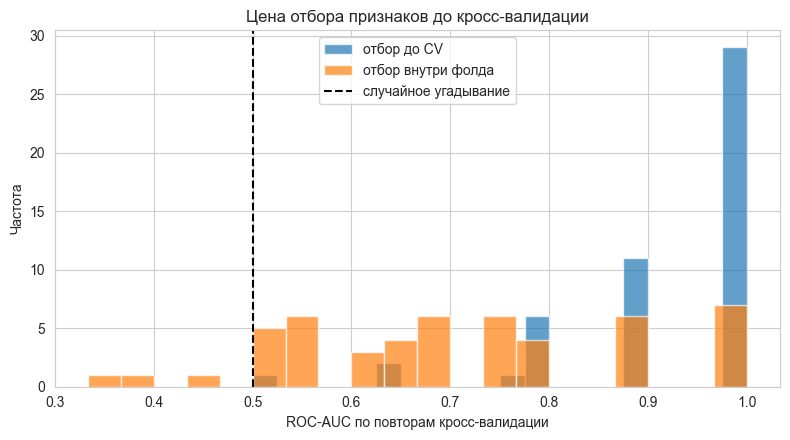

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(leaky_auc, bins=20, alpha=0.7, label="отбор до CV")
ax.hist(honest_auc, bins=20, alpha=0.7, label="отбор внутри фолда")
ax.axvline(0.5, linestyle="--", color="black", label="случайное угадывание")
ax.set_xlabel("ROC-AUC по повторам кросс-валидации")
ax.set_ylabel("Частота")
ax.set_title("Цена отбора признаков до кросс-валидации")
ax.legend()
plt.tight_layout()
plt.show()

Разрыв между двумя оценками — цена ошибки. Обе получены на одних и тех же
данных, одной моделью, с одинаковым числом признаков.

Масштаб стоит соотнести с задачей: константный предсказатель здесь даёт accuracy
около 0.57. Завышение сопоставимо со всем запасом между константой и осмысленным
результатом.

Отдельно: при одном из прогонов в матрице признаков случайно осталась сама
целевая переменная. Отбор по mutual information честно вытащил её на первое
место, и кросс-валидация показала ROC-AUC 0.98. Такая цифра на 30 наблюдениях и
есть главный признак того, что модель видит ответ. В `src/preprocessing.py`
целевая колонка теперь исключается по умолчанию.


## Часть 2. Куда делся 21 человек

Фильтр «заполненность анкеты не ниже 67%» оставляет 30 наблюдений из 51.
Обоснование было такое: у остальных большинство признаков пришлось бы
импутировать, и наблюдение превратилось бы в набор медиан.

Обоснование верное для подхода «сто сырых признаков сразу». Но стоит посмотреть,
как устроена заполненность, прежде чем выбрасывать 40% выборки.


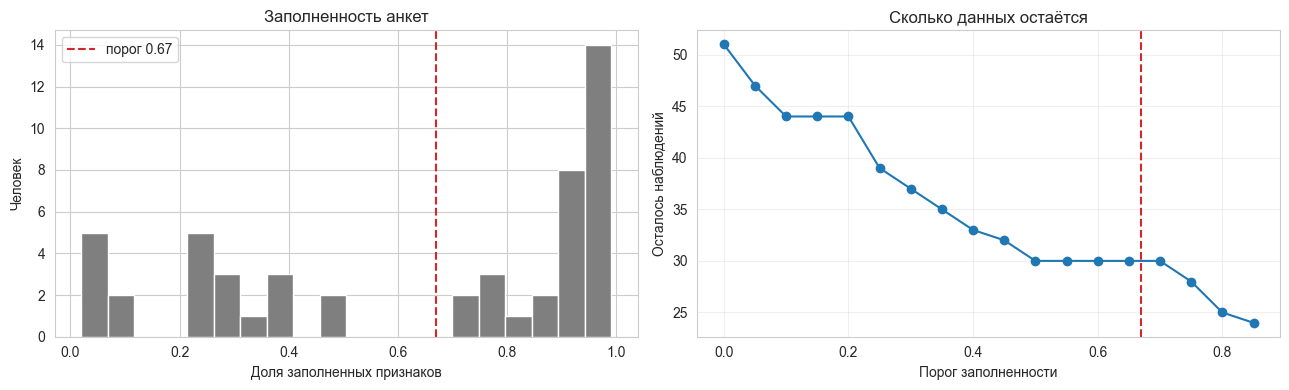

Признаков с заполненностью не ниже:
  90%:   0 признаков
  80%:  22 признаков
  70%:  22 признаков
  60%:  49 признаков
  50%:  91 признаков


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(completeness, bins=20, color="tab:gray", edgecolor="white")
axes[0].axvline(0.67, color="tab:red", linestyle="--", label="порог 0.67")
axes[0].set_xlabel("Доля заполненных признаков")
axes[0].set_ylabel("Человек")
axes[0].set_title("Заполненность анкет")
axes[0].legend()

thresholds = np.arange(0.0, 0.9, 0.05)
kept = [(completeness >= t).sum() for t in thresholds]
axes[1].plot(thresholds, kept, marker="o")
axes[1].axvline(0.67, color="tab:red", linestyle="--")
axes[1].set_xlabel("Порог заполненности")
axes[1].set_ylabel("Осталось наблюдений")
axes[1].set_title("Сколько данных остаётся")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

fill_rate = features.notna().mean()
print("Признаков с заполненностью не ниже:")
for t in (0.9, 0.8, 0.7, 0.6, 0.5):
    print(f"  {t:.0%}: {(fill_rate >= t).sum():3d} признаков")

Распределение бимодальное: часть людей заполнила почти всё, часть — только
отдельные блоки. Промежуточных значений почти нет.

Это меняет постановку. Отсеянные не «плохие» наблюдения с шумом — у них
заполнены целые блоки анкеты и пусты другие. Если считать признаки не по каждому
пункту, а по блокам, эти люди дадут осмысленные значения там, где отвечали.


## Часть 3. Пропуск как информация

Прежде чем чинить пропуски импутацией, стоит проверить, случайны ли они.
Простой тест: предсказывает ли попадание в сборную сам факт того, что человек
ответил на вопросы блока.


In [7]:
probe_blocks = {
    "Участие в турнирах": ["Участие в турнирах"],
    "Лучший результат": ["Лучший результат"],
    "Стаж занятий": ["Стаж занятий"],
    "Физические тесты": ["Ph_"],
    "Самооценка уровня": ["Самооценка текущего"],
}

rows = []
for label, patterns in probe_blocks.items():
    columns = [c for c in features.columns if any(p in c for p in patterns)]
    answered = features[columns].notna().any(axis=1).to_numpy()
    rows.append({
        "блок": label,
        "ответили": int(answered.sum()),
        "в сборной среди ответивших": y[answered].mean() if answered.any() else np.nan,
        "в сборной среди пропустивших": y[~answered].mean() if (~answered).any() else np.nan,
        "ROC-AUC факта ответа": roc_auc_score(y, answered.astype(float)),
    })

probe = pd.DataFrame(rows)
print(probe.round(3).to_string(index=False))

              блок  ответили  в сборной среди ответивших  в сборной среди пропустивших  ROC-AUC факта ответа
Участие в турнирах        28                       0.571                         0.304                 0.634
  Лучший результат        20                       0.800                         0.226                 0.776
      Стаж занятий        28                       0.571                         0.304                 0.634
  Физические тесты        29                       0.448                         0.455                 0.497
 Самооценка уровня        43                       0.488                         0.250                 0.564


Пропуски неслучайны, и разрыв велик: среди ответивших на «лучший результат»
в сборной 80%, среди пропустивших — 23%. Одного факта ответа хватает на
ROC-AUC 0.776.

Физические тесты — контрольный случай: там AUC 0.497, то есть заполнение этого
блока с попаданием в сборную не связано вообще. Значит эффект не в том, что
«старательные заполняют всё», а именно в содержании блока про соревнования.

Отсюда два следствия. Медианная импутация подменяет «не отвечал» на «среднее по
группе» и стирает ровно то, что различает людей. Значит долю заполненных пунктов
блока нужно кодировать явным признаком.


Пропуски не случайны. Тот, кто не выступает на соревнованиях, не отвечает на
вопросы про соревнования — и одного этого факта хватает, чтобы отделить часть
сборной от остальных.

Отсюда два следствия.

**Медианная импутация уничтожает сигнал.** Она подменяет «не отвечал» на
«среднее по группе», то есть стирает ровно то, что различает людей.

**Пропуск нужно кодировать явно.** Доля заполненных пунктов блока — обычный
числовой признак, который модель может использовать наравне с ответами.


## Часть 4. Тематические индексы

Второй инструмент против нехватки данных — уменьшить число признаков не отбором,
а агрегацией.

Пункты внутри блока анкеты измеряют одно и то же разными словами. Вместо ста
колонок строю восемь индексов: среднее z-оценок пунктов блока. Три эффекта:

- **пространство поиска** сокращается с сотни до восьми, отбор признаков
  перестаёт быть основным источником переобучения;
- **шум отдельного ответа** гасится усреднением;
- **пропуски перестают быть фатальными**: индекс считается по тем пунктам,
  которые заполнены, поэтому человек с четырьмя ответами из семи получает
  осмысленное значение, а не выбрасывается.

Определения блоков — в `src/indices.py`. Преобразователь написан так, чтобы
класть его внутрь `Pipeline`: z-оценки считаются на обучающей части фолда, а не
на всей выборке.


In [8]:
indexer = ThematicIndices()
index_matrix = pd.DataFrame(indexer.fit_transform(features), columns=indexer.feature_names_)

print("Заполненность индексов по всем наблюдениям:")
print(index_matrix.notna().mean().round(2).to_string())
print()
print(f"Строк без единого пропуска среди индексов: {index_matrix.notna().all(axis=1).sum()}")
print(f"Строк, где заполнена хотя бы половина:      {(index_matrix.notna().mean(axis=1) >= 0.5).sum()}")

Заполненность индексов по всем наблюдениям:
опыт                          0.55
самооценка                    0.84
мотивация                     0.84
стрессоустойчивость           0.84
физподготовка                 0.55
дисциплина                    0.69
учеба_и_спорт                 0.67
восстановление                0.59
заполнен_блок_соревнований    1.00
заполнен_блок_физтестов       1.00
заполнен_блок_психологии      1.00

Строк без единого пропуска среди индексов: 15
Строк, где заполнена хотя бы половина:      44


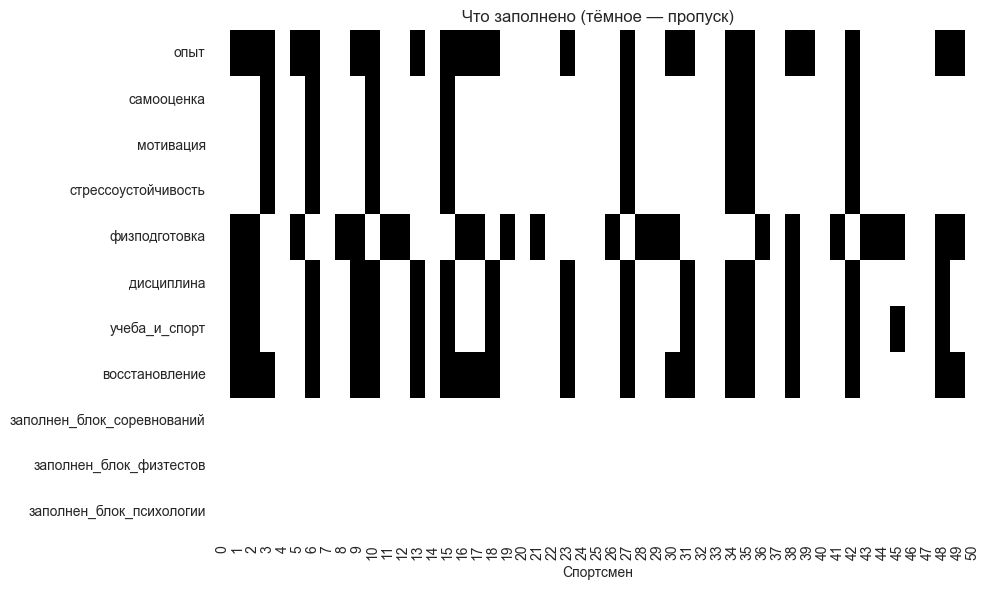

In [9]:
present = index_matrix.notna()
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(present.T, cbar=False, cmap="Greys_r", ax=ax)
ax.set_xlabel("Спортсмен")
ax.set_ylabel("")
ax.set_title("Что заполнено (тёмное — пропуск)")
plt.tight_layout()
plt.show()

## Часть 5. Сравнение конфигураций

Все варианты оцениваются одинаково: повторная стратифицированная
кросс-валидация, всё преобразование внутри пайплайна, метрика ROC-AUC.

Пять конфигураций отвечают на разные вопросы:

- **A** — исходная постановка: строгий фильтр, сто сырых признаков, отбор внутри фолда.
- **B** — только признаки заполненности блоков. Проверка того, сколько даёт
  один лишь факт, кто на какие вопросы отвечал.
- **C** — индексы плюс заполненность, вся выборка.
- **D** — то же, но без соревновательного блока. Самый интересный вариант
  содержательно: можно ли предсказать состав сборной, не зная про турниры.
- **E** — линейная модель на том же наборе, что и C: нужна ли нелинейность.


In [10]:
def index_pipeline(model, drop=(), definitions=None, missingness=None):
    return Pipeline([
        ("indices", ThematicIndices(definitions=definitions, missingness=missingness, drop=drop)),
        ("impute", SimpleImputer(strategy="median")),
        ("model", model),
    ])


logreg = LogisticRegression(C=0.5, class_weight="balanced", max_iter=2000, random_state=SEED)

# конфигурация D: убираем всё, что связано с соревнованиями
definitions_no_compet = {k: v for k, v in INDEX_DEFINITIONS.items() if k != "опыт"}
missingness_no_compet = {k: v for k, v in MISSINGNESS_BLOCKS.items()
                         if k != "заполнен_блок_соревнований"}

setups = {
    "A. строгий фильтр, 100 признаков, top-12": (raw_pipeline(rf), X_strict, y_strict),
    "B. только заполненность блоков":           (index_pipeline(rf, drop=tuple(INDEX_DEFINITIONS)), features, y),
    "C. индексы + заполненность":               (index_pipeline(rf), features, y),
    "D. без соревновательного блока":           (index_pipeline(rf, definitions=definitions_no_compet,
                                                                missingness=missingness_no_compet), features, y),
    "E. индексы + заполненность, логрегрессия": (index_pipeline(logreg), features, y),
}

rows = []
for name, (pipe, X_setup, y_setup) in setups.items():
    scores = cross_val_score(
        pipe, X_setup, y_setup, scoring="roc_auc",
        cv=RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=SEED),
    )
    rows.append({
        "конфигурация": name,
        "наблюдений": len(y_setup),
        "ROC-AUC": scores.mean(),
        "std": scores.std(),
    })

results = pd.DataFrame(rows)
print(results.round(3).to_string(index=False))

                            конфигурация  наблюдений  ROC-AUC   std
A. строгий фильтр, 100 признаков, top-12          30    0.709 0.175
          B. только заполненность блоков          51    0.741 0.155
              C. индексы + заполненность          51    0.835 0.119
          D. без соревновательного блока          51    0.774 0.138
E. индексы + заполненность, логрегрессия          51    0.819 0.120


Что видно из таблицы.

**Одни признаки заполненности (B) уже обгоняют исходную постановку** — 0.741
против 0.709, при том что это три числа против ста признаков. Информация была
в данных всё это время, её уничтожала импутация.

**Индексы плюс заполненность (C) дают 0.835.** Прирост складывается из двух
частей: возвращённые 21 наблюдение и сокращение пространства признаков с ста до
одиннадцати.

**Без соревновательного блока (D) — 0.774.** Слабее, но это единственный
вариант, отвечающий на исходный вопрос работы, а не на вопрос «выступает ли
человек на турнирах».

**Логрегрессия (E) почти не уступает лесу** — 0.819 против 0.835. Нелинейность
здесь ничего принципиального не добавляет, и это хороший знак: на 51 наблюдении
простая модель предпочтительнее.


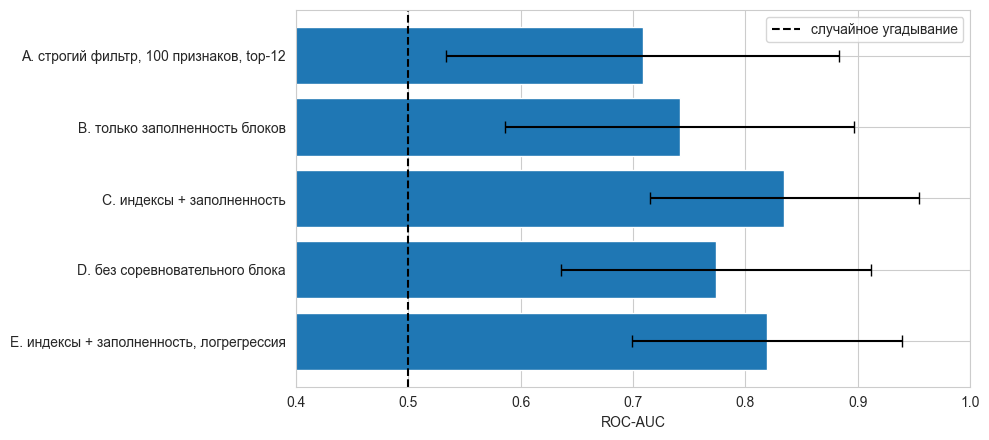

In [11]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.barh(results["конфигурация"], results["ROC-AUC"], xerr=results["std"], capsize=4)
ax.axvline(0.5, linestyle="--", color="black", label="случайное угадывание")
ax.set_xlabel("ROC-AUC")
ax.set_xlim(0.4, 1.0)
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

## Часть 6. Значимы ли результаты

Перестановочный тест: метки перемешиваются, вся процедура повторяется целиком,
и считается, как часто она даёт качество не хуже наблюдаемого.

Проверяю две конфигурации — лучшую по метрике и ту, что без соревновательного
блока. Вторая важнее содержательно: она отвечает на исходный вопрос НИР о
факторах успеха, а не на вопрос «выступает ли этот человек на турнирах».


In [12]:
def run_permutation(name, pipe, X_setup, y_setup):
    score, permutation_scores, p_value = permutation_test_score(
        pipe, X_setup, y_setup,
        scoring="roc_auc",
        cv=StratifiedKFold(N_SPLITS, shuffle=True, random_state=SEED),
        n_permutations=N_PERMUTATIONS,
        random_state=SEED,
        n_jobs=1,
    )
    print(f"{name}")
    print(f"  наблюдаемый ROC-AUC: {score:.3f}")
    print(f"  нулевое распределение: среднее {permutation_scores.mean():.3f}, "
          f"std {permutation_scores.std():.3f}")
    print(f"  95-й перцентиль нулевого: {np.percentile(permutation_scores, 95):.3f}")
    print(f"  p-value: {p_value:.3f}\n")
    return score, permutation_scores, p_value


perm_results = {}
perm_results["C. индексы + заполненность"] = run_permutation(
    "C. индексы + заполненность", index_pipeline(rf), features, y)
perm_results["D. без соревновательного блока"] = run_permutation(
    "D. без соревновательного блока",
    index_pipeline(rf, definitions=definitions_no_compet, missingness=missingness_no_compet),
    features, y)

C. индексы + заполненность
  наблюдаемый ROC-AUC: 0.847
  нулевое распределение: среднее 0.503, std 0.122
  95-й перцентиль нулевого: 0.709
  p-value: 0.005

D. без соревновательного блока
  наблюдаемый ROC-AUC: 0.806
  нулевое распределение: среднее 0.496, std 0.116
  95-й перцентиль нулевого: 0.692
  p-value: 0.005



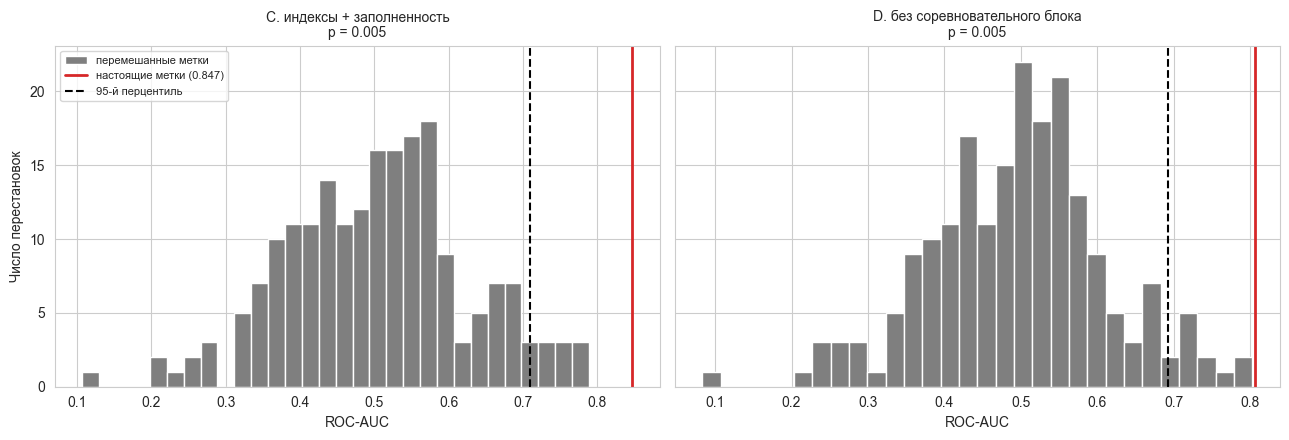

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

for ax, (name, (score, null, p_value)) in zip(axes, perm_results.items()):
    ax.hist(null, bins=30, color="tab:gray", label="перемешанные метки")
    ax.axvline(score, color="tab:red", linewidth=2, label=f"настоящие метки ({score:.3f})")
    ax.axvline(np.percentile(null, 95), linestyle="--", color="black", label="95-й перцентиль")
    ax.set_title(f"{name}\np = {p_value:.3f}", fontsize=10)
    ax.set_xlabel("ROC-AUC")

axes[0].set_ylabel("Число перестановок")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

Обе конфигурации значимы, и с запасом: наблюдаемые 0.847 и 0.806 против 95-х
перцентилей нулевого распределения 0.709 и 0.692. p = 0.005 в обоих случаях.

Для сравнения, в первой версии работы наблюдаемый ROC-AUC был 0.694 при
95-м перцентиле 0.714 — то есть результат не дотягивал до границы, p = 0.073.

Важнее всего вторая строка: **конфигурация D значима, хотя соревновательного
блока в ней нет вовсе**. Психология, мотивация, дисциплина, режим восстановления
и баланс учёбы со спортом различают состав сборной сами по себе.

## Часть 7. Что из этого можно утверждать

In [14]:
# оценка сверху на детектируемый эффект: какая разница между группами
# вообще различима при таком размере выборки
from math import sqrt

n1, n0 = int(y.sum()), int((1 - y).sum())
z_alpha, z_beta = 1.96, 0.84
detectable_d = (z_alpha + z_beta) * sqrt(1 / n1 + 1 / n0)

print(f"Группы: {n1} и {n0} человек")
print(f"Минимальный размер эффекта (d Коэна), различимый с мощностью 80%: {detectable_d:.2f}")
print()
print("Для сравнения: d = 0.2 считается слабым эффектом, 0.5 средним, 0.8 сильным.")
print("То есть выборка позволяет заметить только очень выраженные различия.")

Группы: 23 и 28 человек
Минимальный размер эффекта (d Коэна), различимый с мощностью 80%: 0.79

Для сравнения: d = 0.2 считается слабым эффектом, 0.5 средним, 0.8 сильным.
То есть выборка позволяет заметить только очень выраженные различия.


## Часть 8. Финальная модель

Беру конфигурацию C и смотрю на предсказания через `cross_val_predict`:
предсказание для каждого наблюдения делает модель, которая его не видела.


              precision    recall  f1-score   support

не в сборной      0.750     0.750     0.750        28
     сборная      0.696     0.696     0.696        23

    accuracy                          0.725        51
   macro avg      0.723     0.723     0.723        51
weighted avg      0.725     0.725     0.725        51



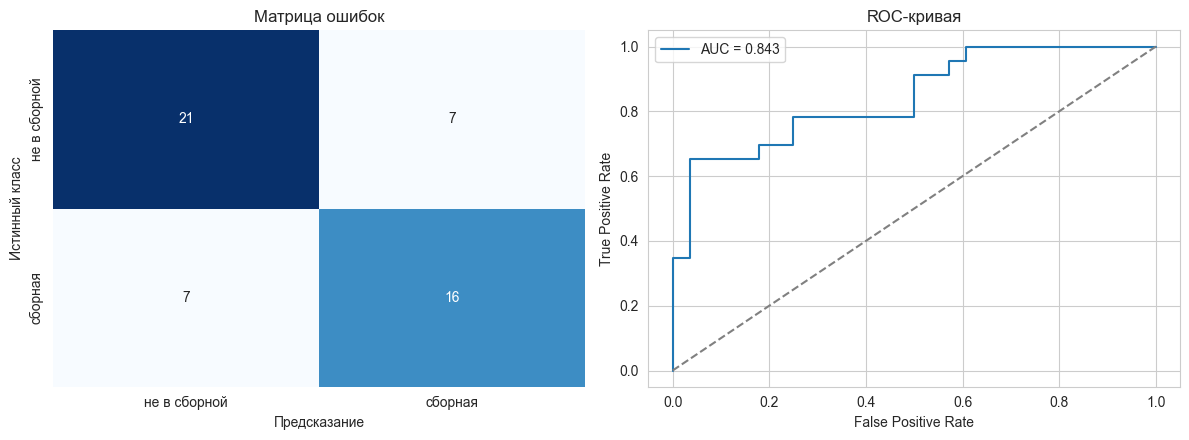

In [15]:
final_pipe = index_pipeline(rf)
single_cv = StratifiedKFold(N_SPLITS, shuffle=True, random_state=SEED)

proba = cross_val_predict(final_pipe, features, y, cv=single_cv, method="predict_proba")[:, 1]
pred = (proba >= 0.5).astype(int)

print(classification_report(y, pred, target_names=["не в сборной", "сборная"], digits=3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.heatmap(confusion_matrix(y, pred), annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["не в сборной", "сборная"],
            yticklabels=["не в сборной", "сборная"], ax=axes[0])
axes[0].set_xlabel("Предсказание")
axes[0].set_ylabel("Истинный класс")
axes[0].set_title("Матрица ошибок")

fpr, tpr, _ = roc_curve(y, proba)
axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y, proba):.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC-кривая")
axes[1].legend()

plt.tight_layout()
plt.show()

Accuracy 0.725 против 0.549 у константного предсказателя, и оба класса
предсказываются сопоставимо: precision и recall около 0.70-0.75 и для сборной,
и для остальных.

Это принципиальное отличие от первой версии, где accuracy бинарных предсказаний
(0.533) была **ниже** константы. Тогда модель кое-как упорядочивала спортсменов,
но при пороге 0.5 работала хуже, чем ответ «все в сборной». Теперь порядок и
решения согласованы.


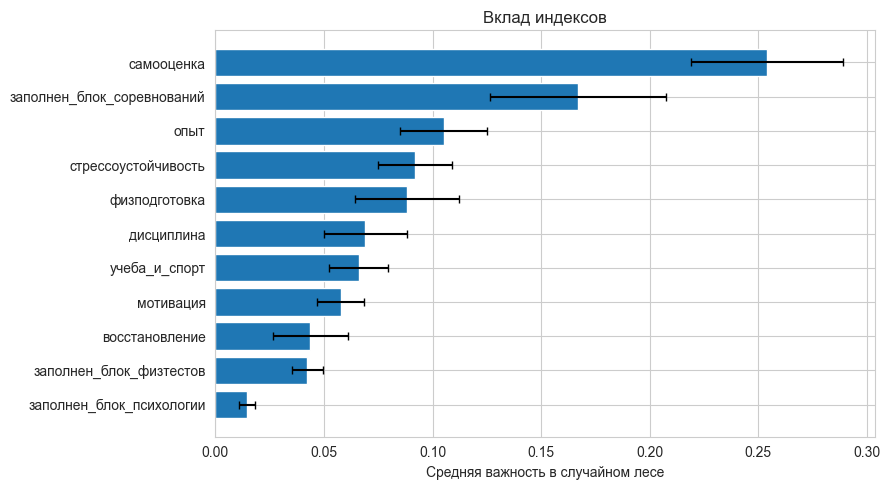

самооценка                    0.254
заполнен_блок_соревнований    0.167
опыт                          0.105
стрессоустойчивость           0.092
физподготовка                 0.088
дисциплина                    0.069
учеба_и_спорт                 0.066
мотивация                     0.058
восстановление                0.044
заполнен_блок_физтестов       0.042
заполнен_блок_психологии      0.015


In [16]:
# вклад индексов: важность признаков усредняется по фолдам
importances = []
splitter = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=SEED)

for train_idx, _ in splitter.split(features, y):
    fitted = index_pipeline(rf).fit(features.iloc[train_idx], y[train_idx])
    importances.append(fitted.named_steps["model"].feature_importances_)

importance = pd.DataFrame(importances, columns=indexer.feature_names_)
order = importance.mean().sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(order.index, order.values, xerr=importance.std()[order.index], capsize=3)
ax.set_xlabel("Средняя важность в случайном лесе")
ax.set_title("Вклад индексов")
plt.tight_layout()
plt.show()

print(importance.mean().sort_values(ascending=False).round(3).to_string())

## Выводы

**Про методику.** Отбор признаков до кросс-валидации завышал accuracy на 18.7
процентных пункта, ROC-AUC — на 0.209. Данные, модель и число признаков при этом
одинаковы, отличается только момент отбора.

**Про данные — главное.** Строгий фильтр по заполненности отсекал 21 наблюдение
из 51. Переход от сырых пунктов к тематическим индексам возвращает их в анализ:
индекс считается по заполненным пунктам блока, поэтому частично заполненная
анкета перестаёт быть бесполезной. ROC-AUC вырос с 0.709 до 0.835, accuracy —
с 0.533 до 0.725 при константе 0.549. Прирост дала работа с данными, а не смена
модели: логистическая регрессия показывает практически то же, что случайный лес.

**Про пропуски.** Они неслучайны: факт ответа на блок про соревнования даёт
ROC-AUC 0.776 сам по себе, а три признака заполненности вместе — 0.741, что уже
выше исходной постановки со ста признаками. Контрольная проверка на физических
тестах (AUC 0.497) показывает, что дело не в общей старательности респондентов.

**Про значимость.** Перестановочный тест даёт p = 0.005 и для полной
конфигурации, и для варианта без соревновательного блока — против p = 0.073 в
первой версии. С поправкой на перебор конфигураций выводы остаются разведочными,
но запас над нулевым распределением здесь принципиально другой.

**Про предметную область.** Наибольший вклад даёт самооценка текущего уровня
игры (0.254), дальше — заполненность блока соревнований (0.167) и сам
соревновательный опыт (0.105). Физподготовка вносит 0.088, наравне с дисциплиной
и балансом учёбы. Для студенческой секции это ожидаемо: разброс общефизической
подготовки невелик, а разброс игрового опыта и самооценки — велик.

Причинность по данным одного среза установить нельзя: участие в турнирах может
быть и причиной попадания в сборную, и его следствием. Самооценка тем более:
уверенность может как способствовать попаданию в сборную, так и следовать из
него.

**Что нужно для надёжного ответа.** Прежде всего данные: при 51 наблюдении
минимальный различимый размер эффекта d ≈ 0.79, то есть выборка ловит только
сильные различия. Для устойчивого вывода нужно 150-200 наблюдений — сбор по
нескольким вузам или несколько сезонов подряд. Второе — сократить анкету,
оставив пункты, которые реально входят в индексы. Третье — повторные измерения
одних и тех же спортсменов, что позволило бы смотреть на динамику.